<a href="https://colab.research.google.com/github/munnurumahesh03-coder/AI-Firewall-NIDS/blob/main/AI_Firewall_NIDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# Import Libraries & Load NSL-KDD Dataset
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Deep Learning & Preprocessing ---
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

print(f"✅ TensorFlow Version: {tf.__version__}")
print("✅ GPU Available: ", tf.config.list_physical_devices('GPU'))

# NSL-KDD doesn't have headers, so we must define the 43 column names manually
columns = (
    ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
     'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
     'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
     'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
     'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
     'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
     'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
     'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
     'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
     'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_class', 'difficulty_level']
)

# Load the data (Make sure the files are uploaded to your Colab session!)
try:
    train_df = pd.read_csv('/content/KDDTrain+.txt', names=columns)
    test_df = pd.read_csv('/content/KDDTest+.txt', names=columns)

    print("\n✅ NSL-KDD Dataset loaded successfully!")
    print(f"Training Data Shape: {train_df.shape}")
    print(f"Testing Data Shape: {test_df.shape}")

    # Display the first 5 rows
    display(train_df.head())
except FileNotFoundError:
    print("\n❌ ERROR: Could not find the .txt files. Please check your Colab file paths!")


✅ TensorFlow Version: 2.20.0
✅ GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ NSL-KDD Dataset loaded successfully!
Training Data Shape: (125973, 43)
Testing Data Shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
# ==============================================================================
# Target Engineering (Binary Classification)
# ==============================================================================
print("=" * 80)
print("Target Engineering: Converting to Binary Classification")
print("=" * 80)

# 1. Drop the 'difficulty_level' column (Prevents Data Leakage!)
for df in [train_df, test_df]:
    if 'difficulty_level' in df.columns:
        df.drop(columns=['difficulty_level'], inplace=True)

# 2. Create the Binary Target Column
# If the class is 'normal', it becomes 0 (Safe). Anything else becomes 1 (Attack).
train_df['is_attack'] = train_df['attack_class'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['is_attack'] = test_df['attack_class'].apply(lambda x: 0 if x == 'normal' else 1)

# 3. Drop the original text column
train_df.drop(columns=['attack_class'], inplace=True)
test_df.drop(columns=['attack_class'], inplace=True)

# 4. Define our new target variable
TARGET = 'is_attack'

# 5. Check the balance of our new target
print("\nTraining Data Target Distribution:")
print(train_df[TARGET].value_counts(normalize=True) * 100)

print("\n✅ Target engineered successfully! 0 = Normal, 1 = Cyberattack")


Target Engineering: Converting to Binary Classification

Training Data Target Distribution:
is_attack
0    53.458281
1    46.541719
Name: proportion, dtype: float64

✅ Target engineered successfully! 0 = Normal, 1 = Cyberattack


In [ ]:
# ==============================================================================
# Mini-EDA & Feature Separation
# ==============================================================================
print("=" * 80)
print("Mini-EDA: Checking Data Health & Separating Features")
print("=" * 80)

# 1. Check for missing values
missing_train = train_df.isnull().sum().sum()
missing_test = test_df.isnull().sum().sum()
print(f"Missing values in Training Data: {missing_train}")
print(f"Missing values in Testing Data: {missing_test}")

# 2. Dynamically separate Numerical and Categorical features
# We exclude the TARGET column so we don't accidentally scale our 0s and 1s!
NUMS = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
NUMS.remove(TARGET)

CATS = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nFound {len(NUMS)} Numerical Features.")
print(f"Found {len(CATS)} Categorical Features: {CATS}")

# 3. Quick look at the Categorical features
print("\nUnique values in Categorical Features:")
for col in CATS:
    print(f" - {col}: {train_df[col].nunique()} unique values")


Mini-EDA: Checking Data Health & Separating Features
Missing values in Training Data: 0
Missing values in Testing Data: 0

Found 38 Numerical Features.
Found 3 Categorical Features: ['protocol_type', 'service', 'flag']

Unique values in Categorical Features:
 - protocol_type: 3 unique values
 - service: 70 unique values
 - flag: 11 unique values


In [ ]:
# ==============================================================================
# Deep Learning Preprocessing (Scaling & Encoding)
# ==============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("=" * 80)
print("Preprocessing: Scaling Math & Encoding Text")
print("=" * 80)

# 1. Separate Features (X) and Target (y)
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET].values

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].values

# 2. Build the Preprocessing Pipeline
# - StandardScaler: Squishes all numbers to be between roughly -3 and 3.
# - OneHotEncoder: Converts text to 1s and 0s. handle_unknown='ignore' prevents crashes!
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATS)
    ])

# 3. Apply the transformations
print("⚙️ Fitting the preprocessor on the training data...")
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"✅ Preprocessing complete!")
print(f"Original Training Shape: {X_train.shape}")
print(f"New Scaled Training Shape: {X_train_scaled.shape} (Notice the extra columns from One-Hot Encoding!)")


Preprocessing: Scaling Math & Encoding Text
⚙️ Fitting the preprocessor on the training data...
✅ Preprocessing complete!
Original Training Shape: (125973, 41)
New Scaled Training Shape: (125973, 122) (Notice the extra columns from One-Hot Encoding!)


In [ ]:
# ==============================================================================
# Building the Deep Learning Architecture
# ==============================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

print("=" * 80)
print("Building the Artificial Neural Network (ANN)")
print("=" * 80)

# 1. Initialize the Sequential Model (A linear stack of layers)
model = Sequential()

# ------------------------------------------------------------------------------
# INPUT LAYER & FIRST HIDDEN LAYER
# ------------------------------------------------------------------------------
# - Dense(128): We create 128 neurons.
# - activation='relu': The industry standard math filter that helps the network learn non-linear patterns.
# - input_shape: We tell the network to expect exactly 122 columns coming in.
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# - BatchNormalization: Stabilizes the math so the network learns faster.
model.add(BatchNormalization())

# - Dropout(0.3): Randomly turns off 30% of the neurons during training to prevent memorization!
model.add(Dropout(0.3))

# ------------------------------------------------------------------------------
# SECOND HIDDEN LAYER
# ------------------------------------------------------------------------------
# We shrink the network down to 64 neurons to force it to compress the patterns.
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# ------------------------------------------------------------------------------
# OUTPUT LAYER
# ------------------------------------------------------------------------------
# - Dense(1): We only need 1 final neuron to give us the answer.
# - activation='sigmoid': This squishes the final math into a probability between 0.0 and 1.0.
#   (e.g., 0.05 = 5% chance of attack -> Normal. 0.98 = 98% chance of attack -> Hacker!)
model.add(Dense(1, activation='sigmoid'))

# Print the blueprint of our brain!
model.summary()


Building the Artificial Neural Network (ANN)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,833 (97.00 KB)

 Trainable params: 24,449 (95.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# ==============================================================================
# Compiling & Callbacks (The Training Rules)
# ==============================================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("=" * 80)
print("Compiling the Model & Setting up Callbacks")
print("=" * 80)

# 1. Compile the Model
# - optimizer='adam': The industry-standard algorithm that updates the weights.
# - loss='binary_crossentropy': The math formula used to calculate how "wrong" the model is for 0s and 1s.
# - metrics=['accuracy']: We want to see the human-readable accuracy percentage.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. Set up Early Stopping
# If the validation loss doesn't improve for 5 epochs, STOP.
# restore_best_weights=True ensures we keep the best version, not the overfitted version!
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. Set up Learning Rate Scheduler
# If the validation loss gets stuck for 2 epochs, cut the learning rate in half (factor=0.5).
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

print("✅ Model compiled with Adam optimizer and Binary Crossentropy loss.")
print("✅ Early Stopping and ReduceLROnPlateau callbacks are ready.")


Compiling the Model & Setting up Callbacks
✅ Model compiled with Adam optimizer and Binary Crossentropy loss.
✅ Early Stopping and ReduceLROnPlateau callbacks are ready.


In [ ]:
# ==============================================================================
# Training the Neural Network
# ==============================================================================
import time

print("=" * 80)
print("Training the Deep Learning Model on GPU")
print("=" * 80)

# 1. Create the Validation Set (20% of the training data)
# stratify=y_train ensures the 53/46 Normal/Attack ratio is perfectly preserved!
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"Training on {X_tr.shape[0]} rows, Validating on {X_val.shape[0]} rows...\n")

start_time = time.time()

# 2. Train the Model (The Heavy Lifting)
# - epochs=50: The maximum number of times the network will read the entire dataset.
# - batch_size=256: The network will look at 256 rows at a time before updating its math. (Perfect for GPUs)
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

train_time = time.time() - start_time
print(f"\n✅ Training Complete in {train_time:.2f} seconds!")


Training the Deep Learning Model on GPU
Training on 100778 rows, Validating on 25195 rows...

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9694 - loss: 0.0858 - val_accuracy: 0.9889 - val_loss: 0.0327 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0364 - val_accuracy: 0.9898 - val_loss: 0.0261 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0303 - val_accuracy: 0.9924 - val_loss: 0.0218 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9908 - loss: 0.0267 - val_accuracy: 0.9927 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9917 - loss: 0.0245 - val_accuracy: 0.9932 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9924 - loss: 0.0220 - val_accuracy: 0.9936 - val_loss: 0.0183 - learning_rate:

Plotting Training vs. Validation Performance


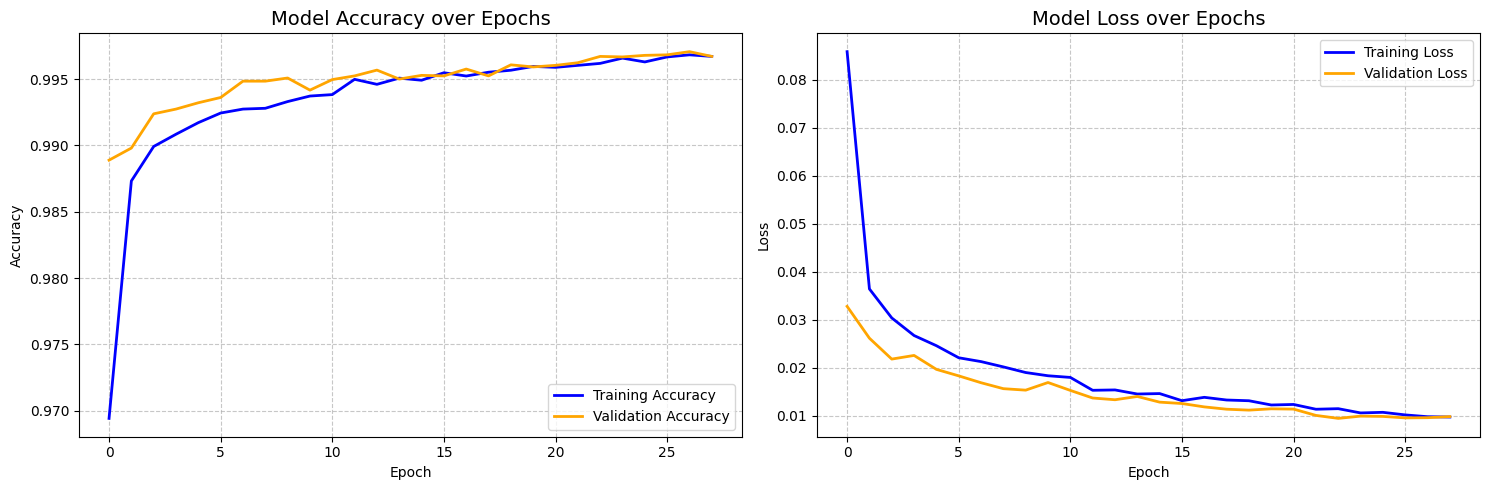

In [ ]:
# ==============================================================================
# Visualizing the Learning Curves (Proof of No Overfitting)
# ==============================================================================
import matplotlib.pyplot as plt

print("=" * 80)
print("Plotting Training vs. Validation Performance")
print("=" * 80)

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ------------------------------------------------------------------------------
# Plot 1: Accuracy
# ------------------------------------------------------------------------------
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.7)

# ------------------------------------------------------------------------------
# Plot 2: Loss (The most important metric for overfitting)
# ------------------------------------------------------------------------------
ax2.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax2.set_title('Model Loss over Epochs', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Evaluating Model on the Unseen Test Set (KDDTest+.txt)
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

  Normal (0)       0.68      0.95      0.79      9711
  Attack (1)       0.95      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.83      0.79      0.78     22544



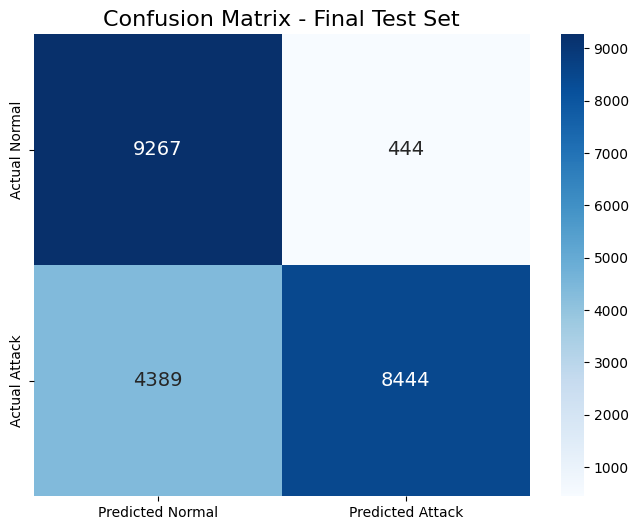

In [ ]:
# ==============================================================================
# Final Evaluation on Unseen Test Data (The Ultimate Test)
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

print("=" * 80)
print("Evaluating Model on the Unseen Test Set (KDDTest+.txt)")
print("=" * 80)

# 1. Predict the probabilities for the Test Set
# The model will output percentages (e.g., 0.05 or 0.98)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convert probabilities to Binary Classes (0 or 1)
# If the probability is > 50% (0.5), we classify it as an Attack (1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 3. Print the Classification Report
print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)']))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix - Final Test Set', fontsize=16)
plt.show()


In [ ]:
# ==============================================================================
# Model Serialization (Saving for Deployment)
# ==============================================================================
import joblib

print("=" * 80)
print("Saving the Preprocessor and Model for Deployment")
print("=" * 80)

# 1. Save the Preprocessor (StandardScaler + OneHotEncoder)
# We use joblib because it is highly optimized for Scikit-Learn objects
joblib.dump(preprocessor, 'nsl_kdd_preprocessor.pkl')
print("✅ Preprocessor saved successfully as 'nsl_kdd_preprocessor.pkl'")

# 2. Save the Deep Learning Model
# We use the modern .keras format (recommended by TensorFlow/Keras)
model.save('nsl_kdd_ann_model.keras')
print("✅ Deep Learning Model saved successfully as 'nsl_kdd_ann_model.keras'")

print("\n🚀 PROJECT READY FOR HUGGING FACE DEPLOYMENT!")

Saving the Preprocessor and Model for Deployment
✅ Preprocessor saved successfully as 'nsl_kdd_preprocessor.pkl'
✅ Deep Learning Model saved successfully as 'nsl_kdd_ann_model.keras'

🚀 PROJECT READY FOR HUGGING FACE DEPLOYMENT!


Finding the Top 10 Features using LightGBM
⚡ Training LightGBM to rank features...
[LightGBM] [Info] Number of positive: 58630, number of negative: 67343
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3228
[LightGBM] [Info] Number of data points in the train set: 125973, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465417 -> initscore=-0.138552
[LightGBM] [Info] Start training from score -0.138552


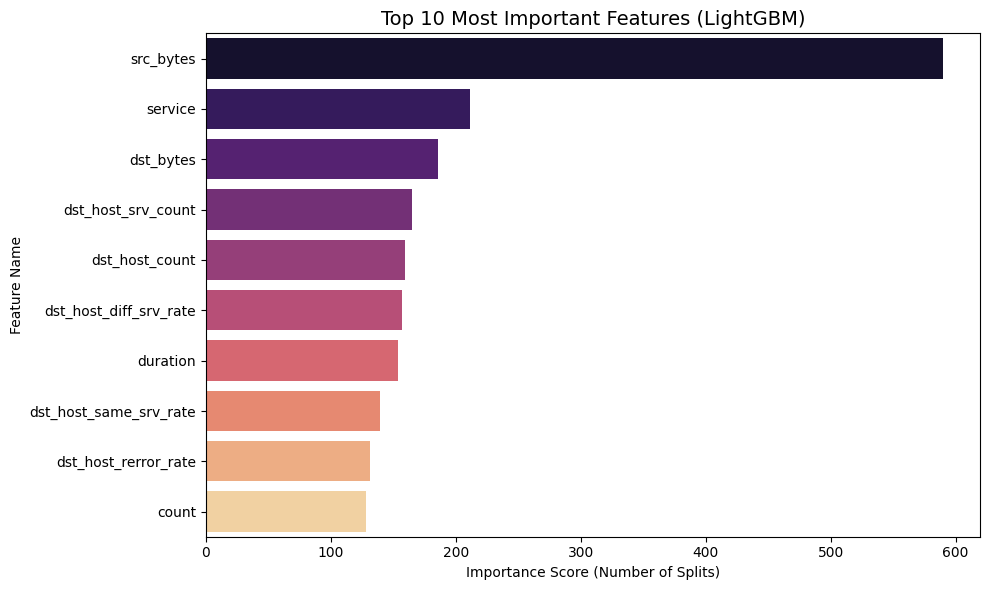


✅ THE TOP 10 FEATURES WE WILL USE FOR THE UI:
1. src_bytes
2. service
3. dst_bytes
4. dst_host_srv_count
5. dst_host_count
6. dst_host_diff_srv_rate
7. duration
8. dst_host_same_srv_rate
9. dst_host_rerror_rate
10. count


In [ ]:
# ==============================================================================
#  Feature Selection using LightGBM (The Modern Approach)
# ==============================================================================
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("Finding the Top 10 Features using LightGBM")
print("=" * 80)

# 1. Prepare data for LightGBM (it loves pandas 'category' dtype)
X_lgb = X_train.copy()
for col in ['protocol_type', 'service', 'flag']:
    X_lgb[col] = X_lgb[col].astype('category')

# 2. Train a fast LightGBM model
print("⚡ Training LightGBM to rank features...")
lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
lgb_model.fit(X_lgb, y_train)

# 3. Extract and sort the importances
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_10_features = importances.head(10)['Feature'].tolist()

# 4. Plot the Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='magma')
plt.title('Top 10 Most Important Features (LightGBM)', fontsize=14)
plt.xlabel('Importance Score (Number of Splits)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

print("\n✅ THE TOP 10 FEATURES WE WILL USE FOR THE UI:")
for i, feat in enumerate(top_10_features, 1):
    print(f"{i}. {feat}")


In [ ]:
# ==============================================================================
# Building the Lightweight Edge Model (For the UI)
# ==============================================================================

print("=" * 80)
print("Training the Lightweight Edge Model (Top 10 Features)")
print("=" * 80)

# 1. Slice the data to ONLY the Top 10 Features
X_train_top10 = X_train[top_10_features]
X_test_top10 = X_test[top_10_features]

# 2. Dynamically sort the Top 10 into Numbers and Categories
top10_cats = [col for col in top_10_features if col in CATS]
top10_nums = [col for col in top_10_features if col in NUMS]

print(f"Categorical Features to Encode: {top10_cats}")
print(f"Numerical Features to Scale: {top10_nums}\n")

# 3. Build the new Preprocessor
preprocessor_top10 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), top10_nums),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), top10_cats)
    ])

X_train_scaled_top10 = preprocessor_top10.fit_transform(X_train_top10)
X_test_scaled_top10 = preprocessor_top10.transform(X_test_top10)

print(f"New Scaled Shape: {X_train_scaled_top10.shape} columns (Much smaller!)\n")

# 4. Build a slightly smaller, faster ANN
model_top10 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled_top10.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_top10.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the Edge Model
X_tr_10, X_val_10, y_tr_10, y_val_10 = train_test_split(
    X_train_scaled_top10, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("🚀 Training the Edge Model...")
history_top10 = model_top10.fit(
    X_tr_10, y_tr_10,
    validation_data=(X_val_10, y_val_10),
    epochs=20, # 20 is plenty for a lightweight model
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Training the Lightweight Edge Model (Top 10 Features)
Categorical Features to Encode: ['service']
Numerical Features to Scale: ['src_bytes', 'dst_bytes', 'dst_host_srv_count', 'dst_host_count', 'dst_host_diff_srv_rate', 'duration', 'dst_host_same_srv_rate', 'dst_host_rerror_rate', 'count']

New Scaled Shape: (125973, 79) columns (Much smaller!)

🚀 Training the Edge Model...
Epoch 1/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9419 - loss: 0.1537 - val_accuracy: 0.9653 - val_loss: 0.1026 - learning_rate: 0.0010
Epoch 2/20
374/394 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9643 - loss: 0.1006
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9659 - loss: 0.0959 - val_accuracy: 0.9682 - val_loss: 0.0795 - learning_rate: 0.0010
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9693 - loss: 0.0850 - val_accuracy: 0.9701 - val_loss: 0.0724 - learning_rate: 5.0000e-04
Epoch 4/20

In [ ]:
%%writefile app.py
import gradio as gr
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# 1. Load the Edge Assets
model_top10 = load_model('edge_model.keras')
preprocessor_top10 = joblib.load('edge_preprocessor.pkl')
top_10_features = joblib.load('edge_columns.pkl')

# 2. Define the Prediction Function
def predict_edge(src_bytes, service, dst_bytes, dst_host_srv_count, dst_host_count,
                 dst_host_diff_srv_rate, duration, dst_host_same_srv_rate, dst_host_rerror_rate, count):

    # Put the inputs into a dictionary
    data = {
        'src_bytes': [src_bytes], 'service': [service], 'dst_bytes': [dst_bytes],
        'dst_host_srv_count': [dst_host_srv_count], 'dst_host_count': [dst_host_count],
        'dst_host_diff_srv_rate': [dst_host_diff_srv_rate], 'duration': [duration],
        'dst_host_same_srv_rate': [dst_host_same_srv_rate], 'dst_host_rerror_rate': [dst_host_rerror_rate],
        'count': [count]
    }

    # Convert to DataFrame
    df = pd.DataFrame(data)[top_10_features]

    # Predict
    X_scaled = preprocessor_top10.transform(df)
    pred_prob = model_top10.predict(X_scaled, verbose=0)[0][0]

    if pred_prob > 0.5:
        return f"🚨 ATTACK DETECTED! (Confidence: {pred_prob*100:.2f}%)"
    else:
        return f"✅ NORMAL TRAFFIC (Confidence: {(1-pred_prob)*100:.2f}%)"

# 3. Build the Gradio Interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🛡️ AI Firewall: Intrusion Detection System")
    gr.Markdown("Adjust the network traffic parameters below to see if the AI blocks the connection.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🌐 Connection Details")
            service = gr.Dropdown(choices=['http', 'private', 'domain_u', 'smtp', 'ftp_data', 'other'], label="Network Service", value='http', allow_custom_value=True )
            duration = gr.Number(label="Duration (seconds)", value=0)
            src_bytes = gr.Number(label="Source Bytes (Data sent)", value=215)
            dst_bytes = gr.Number(label="Destination Bytes (Data received)", value=456)
            count = gr.Number(label="Connection Count (Past 2 seconds)", value=1)

        with gr.Column():
            gr.Markdown("### 🖥️ Host Server Metrics")
            dst_host_count = gr.Number(label="Destination Host Count", value=255)
            dst_host_srv_count = gr.Number(label="Destination Host Server Count", value=255)
            dst_host_same_srv_rate = gr.Slider(0.0, 1.0, label="Same Service Rate (%)", value=1.0)
            dst_host_diff_srv_rate = gr.Slider(0.0, 1.0, label="Diff Service Rate (%)", value=0.0)
            dst_host_rerror_rate = gr.Slider(0.0, 1.0, label="REJ Error Rate (%)", value=0.0)

    submit_btn = gr.Button("🔍 Analyze Traffic", variant="primary")
    output_box = gr.Textbox(label="Firewall Decision", lines=2)

    submit_btn.click(
        fn=predict_edge,
        inputs=[src_bytes, service, dst_bytes, dst_host_srv_count, dst_host_count,
                dst_host_diff_srv_rate, duration, dst_host_same_srv_rate, dst_host_rerror_rate, count],
        outputs=output_box
    )

if __name__ == "__main__":
    demo.launch()


Overwriting app.py


In [ ]:
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
import joblib
import gradio as gr

print("🔍 EXACT VERSIONS USED FOR TRAINING & UI:")
print("-" * 40)
print(f"gradio=={gr.__version__}")
print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"tensorflow=={tf.__version__}")
print(f"joblib=={joblib.__version__}")


🔍 EXACT VERSIONS USED FOR TRAINING & UI:
----------------------------------------
gradio==6.20.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
tensorflow==2.20.0
joblib==1.5.3


In [ ]:
%%writefile requirements.txt
gradio==6.20.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
tensorflow==2.20.0
joblib==1.5.3

Overwriting requirements.txt
